In [1]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset.tail()

--2026-03-10 09:42:01--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.2.33, 104.26.3.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0.002s  

2026-03-10 09:42:02 (29.0 MB/s) - ‘insurance.csv’ saved [50264/50264]



,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [3]:
from sklearn.model_selection import train_test_split

# Preprocess the data
dataset_copy = dataset.copy() # Work on a copy to avoid modifying original dataset

# One-hot encode categorical features
dataset_copy = pd.get_dummies(dataset_copy, columns=['sex', 'smoker', 'region'], prefix='', prefix_sep='')

# Separate features and labels
labels = dataset_copy['expenses']
features = dataset_copy.drop('expenses', axis=1)

# Split the data into training and testing sets
train_dataset, test_dataset, train_labels, test_labels = train_test_split(
    features, labels, test_size=0.2, random_state=42 # Using a fixed random_state for reproducibility
)


# Normalize the data (Crucial for regression models)

normalizer = layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_dataset))

# Build the Sequential model
model = keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # Single output node (no activation function) because we are predicting a continuous price
])

#  Compile the model
# i strictly include 'mae' and 'mse' in our metrics to satisfy the final testing cell
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mae',
    metrics=['mae', 'mse']
)

#  Train the model
print("Training model...")
history = model.fit(
    train_dataset,
    train_labels,
    epochs=100,
    validation_split=0.2, # Hold back 20% of training data to validate after each epoch
    verbose=0 # Hides the massive wall of text for all 100 epochs
)
print("Training complete!")

Training model...
Training complete!


9/9 - 0s - 40ms/step - loss: 2175.2896 - mae: 2175.2896 - mse: 22798988.0000
Testing set Mean Abs Error: 2175.29 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


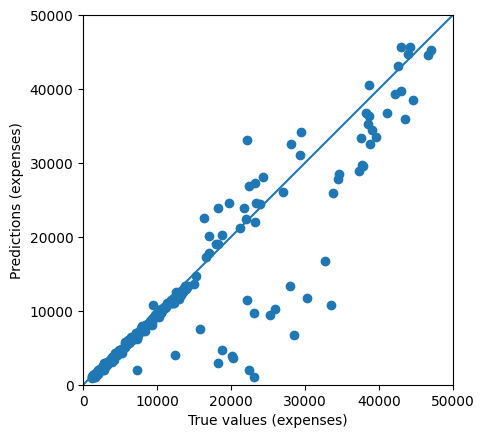

In [4]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)


In [5]:
model.save("health_insurance_predictor.keras")
print("Model saved!")

Model saved!
